# **Lab 4 - Retea neuronala convolutionala pentru recunoastere categorii de imbracaminte/incaltaminte**

Ne propunem sa construim o retea neuronala convolutionala care sa identifice categorii de imbracaminte/incaltaminte plecand de la niste imagini. Reteaua se va antrena pe o colectie de imagini de obiecte cu dimensiunea 28x28 pixeli si va primi ca multime de testare imagini de acelasi tip. Va recunoaste obiectele din imaginile din multimea de testare.

Colectia de date este inclusa in **tf.keras.datasets**.


In [0]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

2025-11-02 08:45:02.070026: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-02 08:45:02.141472: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-02 08:45:02.223342: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-02 08:45:04.991553: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TensorFlow version: 2.16.1


In [0]:
import numpy as np
import matplotlib.pyplot as plt

## Colectia FASHION_MNIST

este o colectie mare de date de imagini de obiecte de imbracaminte si incaltaminte.

Baza de date contine 60.000 de imagini in mt de training si 10.000 de imagini de testare.

## Semnificatia celor 10 valori de iesire
label_class = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
 'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot']


In [0]:
#incarcam baza de date
# https://www.tensorflow.org/api_docs/python/tf/keras/datasets

fashion_mnist = tf.keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

Prima imagine

In [0]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

In [0]:
x_train.shape

(60000, 28, 28)

In [0]:
x_test.shape

(10000, 28, 28)

In [0]:
x_train, x_test = x_train / 255.0, x_test / 255.0

In [0]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [0]:
# semnificatia celor 10 valori de iesire
label_class = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
 'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot']

Primele 10 imagini

In [0]:
# Ce obiecte reprezinta primele 10 imagini
for x in y_train[:10]:
  print(label_class[x])

Ankle boot
T-shirt/top
T-shirt/top
Dress
T-shirt/top
Pullover
Sneaker
Pullover
Sandal
Sandal


Primul obiect

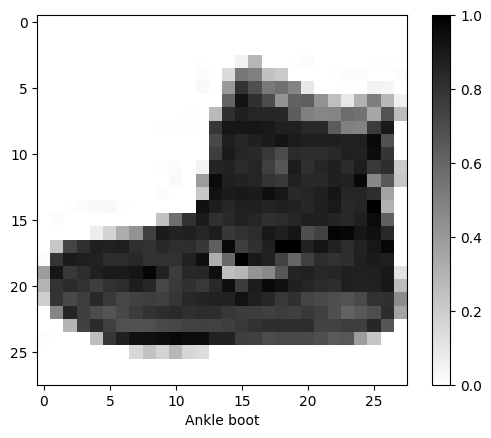

In [0]:
plt.figure()
plt.imshow(x_train[0], cmap=plt.cm.binary)
plt.xlabel(label_class[y_train[0]])
plt.colorbar()
plt.grid(False)
plt.show()

Primele 20 obiecte din  multimea de training.

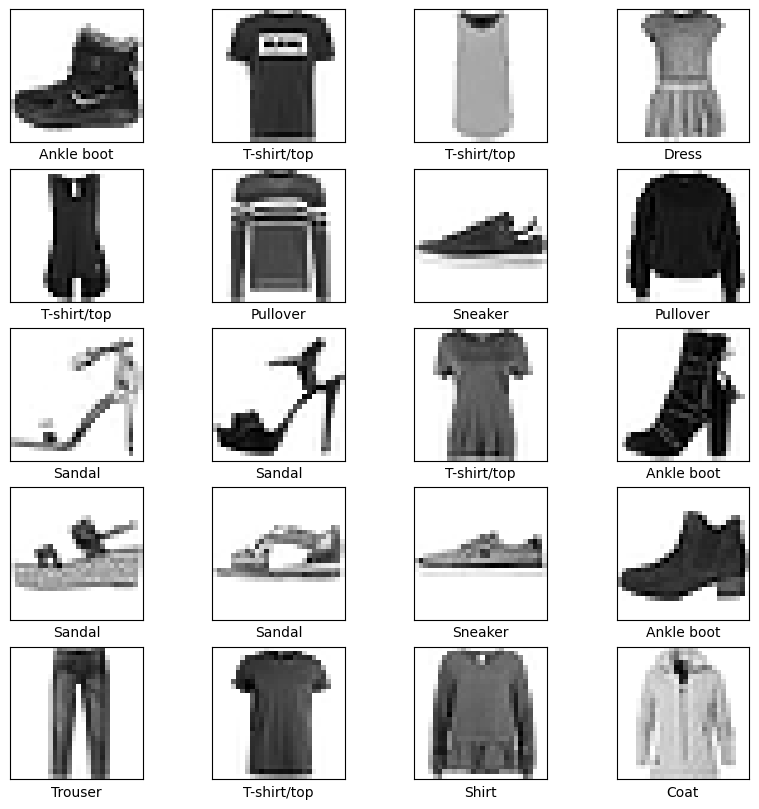

In [0]:
plt.figure(figsize=(10,10))
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(label_class[y_train[i]])
plt.show()

Primele 20 obiecte din multimea de testare.

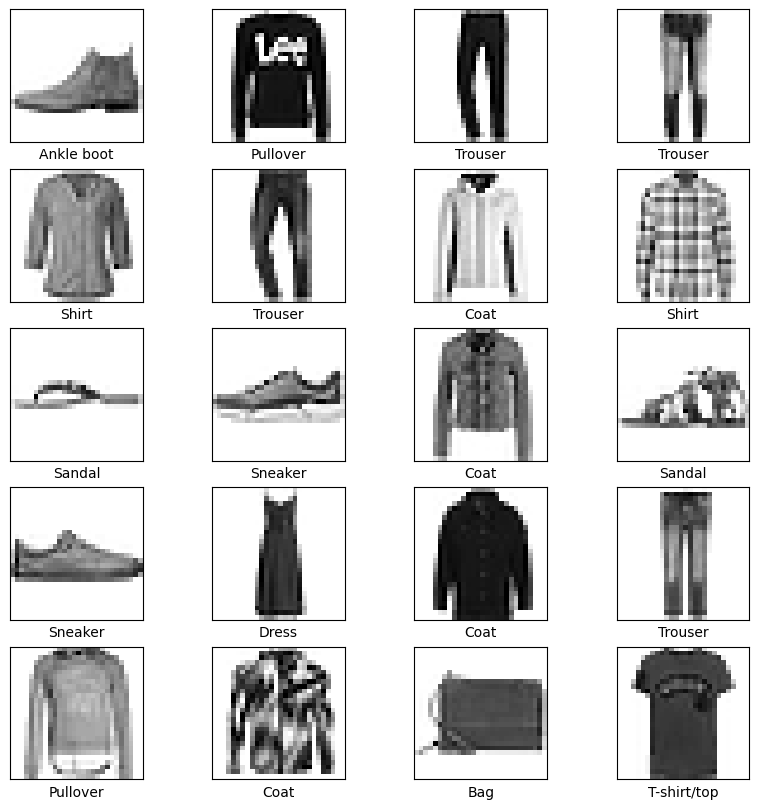

In [0]:
plt.figure(figsize=(10,10))
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[i], cmap=plt.cm.binary)
    plt.xlabel(label_class[y_test[i]])
plt.show()

## **Construire model - retea neuronala convolutionala**

In [0]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(
        filters=32, # numarul de filtre
        kernel_size=(3, 3), # dimensiunea filtrului/convolutiei
        strides=(1, 1), # dimensiunea pasului
        padding='valid', # fara padding (fara bordura suplimentara)
        activation='relu',
        input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2), # dimensiunea filtrului de agregare
        strides=(2, 2) ), # pasul
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])


/databricks/python/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [0]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

### **Compilarea modelului**

Alegem ca functie loss - entropia deoarece atributul tinta este discret si multiclass. Am explicat in Lab1_Curs_DL de ce alegem parametrul from_logits=True.

**adam** este tehnica de alegere a ratei de invatare.

In [0]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

### **Antrenarea modelului**

Se aplica functia **fit** pe multimea de training si cu atributul tinta y_train.

In [0]:
model.fit(x_train, y_train, epochs= 10)

Epoch 1/10
 336/1875 ━━━━━━━━━━━━━━━━━━━━ 37s

*** WARNING: max output size exceeded, skipping output. ***

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9764 - loss: 0.0660


### **Evaluarea modelului pe multimea de testare**

In [0]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9164 - loss: 0.3145


[0.30415472388267517, 0.9162999987602234]

**Acuratetea modelului pe multimea de testare este 0.9189.**

In [0]:
# obtinem predictiile pe multimea de testare

predictions = model.predict(x_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [0]:
predictions.shape

(10000, 10)

Pentru fiecare imagine din multimea de testare obtinem un vector cu 10 valori, fiecare pentru o categorie de imbracaminte.

In [0]:
# pentru prima imagine din multimea de testare

predictions[0]

array([ -4.164695  ,  -9.671245  ,  -5.533376  , -12.409172  ,
       -10.892964  ,  -2.454805  , -12.437108  ,  -0.94389415,
       -10.163326  ,  11.071394  ], dtype=float32)

Observam ca valorile sunt reale.

Acesta este un vector de scoruri de logit adica un vector de valori ce reprezinta probabilitatea logaritmica a fiecarei clase.

In loc sa se prezica direct probabilitatea fiecarei clase se prezice logaritmul sansei de a apartine aceleasi clase.

Aplicam softmax pentru a transforma valorile obtinute in probabilitati.

In [0]:
predictions = tf.nn.softmax(predictions)


In [0]:
predictions[0]

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([2.4157242e-07, 9.8080699e-10, 6.1466196e-08, 6.3462381e-11,
       2.8906574e-10, 1.3354969e-06, 6.1713974e-11, 6.0509446e-06,
       5.9961824e-10, 9.9999219e-01], dtype=float32)>

In [0]:
np.argmax(predictions[10]) # argumentul celei mai mari valori dintre toate probabilitatile
                          # si deci valoarea considerata ca valoare estimata pentru prima imagine

4

In [0]:
estimare_0 = label_class[np.argmax(predictions[0])] # estimare a tipului de obiect
                                                    # din prima imagine din multimea de testare
estimare_0

'Ankle boot'

----------------------------------------

## Overfitting

### Rezolvare prin determinare nr de iteratii (epochs) optim

Observam ca acuratetea este mai mica pe mt de testare decat pe mt de training. Inseamna ca avem cazul **overfitting. (supra-ajustare)**

Reluam modelarea. Folosim 20% din multimea de antrenare ca multime de validare.

Reluam modelarea.

In [0]:
 model1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        strides=(1, 1),
        padding='valid',
        activation='relu',
        input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

 model1.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

 # pastram in variabila history istoricul valorilor functiilor loss si accuracy pe parcursul antrenarii
 # antrenare model cu mt de training = 0.8 si mt de validare = 0.2 din x_train

 history = model1.fit(x_train, y_train, validation_split = 0.2, epochs=10)

/databricks/python/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/10
 370/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.7220 - loss: 0.8038

*** WARNING: max output size exceeded, skipping output. ***

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9731 - loss: 0.0739 - val_accuracy: 0.9201 - val_loss: 0.3001


In [0]:
# history.history este un dictionar
history.history

{'accuracy': [0.8547499775886536,
  0.898812472820282,
  0.9148333072662354,
  0.9267500042915344,
  0.9359166622161865,
  0.9461666941642761,
  0.953416645526886,
  0.9607916474342346,
  0.9660000205039978,
  0.9730208516120911],
 'loss': [0.41354355216026306,
  0.28030359745025635,
  0.23338373005390167,
  0.1999262124300003,
  0.17457903921604156,
  0.14702540636062622,
  0.12689925730228424,
  0.10682845115661621,
  0.09219647198915482,
  0.07555586099624634],
 'val_accuracy': [0.890666663646698,
  0.9040833115577698,
  0.9104166626930237,
  0.909500002861023,
  0.9154999852180481,
  0.9090833067893982,
  0.9101666808128357,
  0.9128333330154419,
  0.9108333587646484,
  0.9200833439826965],
 'val_loss': [0.30865463614463806,
  0.27164608240127563,
  0.24695415794849396,
  0.2491912841796875,
  0.24353240430355072,
  0.2648952901363373,
  0.27403804659843445,
  0.27898532152175903,
  0.29304441809654236,
  0.30006057024002075]}

In [0]:
# cheile dictionarului sunt:['loss', 'accuracy', 'val_loss', 'val_accuracy']

history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [0]:
loss = history_dict['loss'] # valorile functiei loss pe mt de training pt toate iteratiile
loss
val_loss = history_dict['val_loss'] # valorile functiei loss pe mt de validare pt toate iteratiile
val_loss

[0.30865463614463806,
 0.27164608240127563,
 0.24695415794849396,
 0.2491912841796875,
 0.24353240430355072,
 0.2648952901363373,
 0.27403804659843445,
 0.27898532152175903,
 0.29304441809654236,
 0.30006057024002075]

Reprezentare grafica a functiei loss obtinute pentru cele doua multimi, de training si de validare.

In [0]:
epochs = range(1, len(loss)+1)
epochs

range(1, 11)

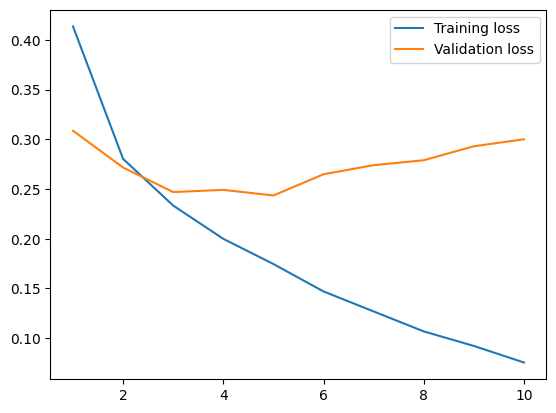

In [0]:
plt.plot(epochs, loss, label = 'Training loss')
plt.plot(epochs, val_loss, label = 'Validation loss')
plt.legend()
plt.show()

Graficul de mai sus sugereaza ca pt epochs >=7 valorile functiei pierdere nu mai descresc pe mt de validare, ci doar pe mt de training, deci avem un caz de overfitting.

Nr optim =  6 iteratii

Reprezentare grafica a functiei accuracy obtinute pentru cele doua multimi, de training si de validare.

In [0]:
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

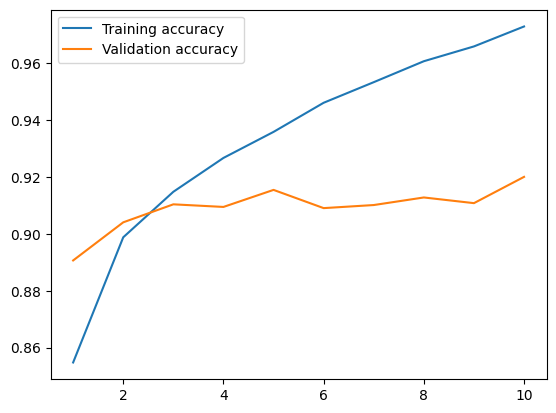

In [0]:
plt.plot(epochs, accuracy, label = 'Training accuracy')
plt.plot(epochs, val_accuracy, label = 'Validation accuracy')
plt.legend()
plt.show()

Aceeasi concluzie si din analiza graficului functiilor accuracy pentru mt de training si mt de testare.

Graficul de mai sus sugereaza ca pt epochs >=7 valorile functiei accuracy nu mai cresc pe mt de validare, ci doar pe mt de training, deci avem un caz de overfitting.

Nr optim = 6 iteratii

Remodelare pt epochs = 6.

In [0]:
model1_optim = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(
        filters=32, # How many filters we will learn
        kernel_size=(3, 3), # Size of feature map that will slide over image
        strides=(1, 1), # How the feature map "steps" across the image
        padding='valid', # We are not using padding
        activation='relu', # Rectified Linear Unit Activation Function
        input_shape=(28, 28, 1)), # The expected input shape for this layer
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2), # Size feature will be mapped to
        strides=(2, 2) ), # How the pool "steps" across the feature
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

model1_optim.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

 # pastram in variabila history istoricul valorilor functiilor loss si accuracy pe parcursul antrenarii
 # antrenare model cu mt de training = 0.8 si mt de validare = 0.2 din x_train

history = model1_optim.fit(x_train, y_train, validation_split = 0.2, epochs=6)

/databricks/python/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/6
[

*** WARNING: max output size exceeded, skipping output. ***

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 91s 45ms/step - accuracy: 0.9477 - loss: 0.1418 - val_accuracy: 0.9112 - val_loss: 0.2619


Evaluarea modelului

In [0]:
model1_optim.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9080 - loss: 0.2755


[0.27077019214630127, 0.9093000292778015]

**Accuratetea pe multimea de testare = 0.9130**

###Rezolvare prin dropout - dezactivarea unor neuroni

In [0]:
model2 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(
        filters=32, # How many filters we will learn
        kernel_size=(3, 3), # Size of feature map that will slide over image
        strides=(1, 1), # How the feature map "steps" across the image
        padding='valid', # We are not using padding
        activation='relu', # Rectified Linear Unit Activation Function
        input_shape=(28, 28, 1)), # The expected input shape for this layer
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2), # Size feature will be mapped to
        strides=(2, 2) ), # How the pool "steps" across the feature
    tf.keras.layers.Dropout(0.25), # 25% dintre neuroni sunt dezactivati
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10)
])

model2.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

 # pastram in variabila history istoricul valorilor functiilor loss si accuracy pe parcursul antrenarii
 # antrenare model cu mt de training = 0.8 si mt de validare = 0.2 din x_train

history = model2.fit(x_train, y_train, validation_split = 0.2, epochs=6)

/databricks/python/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/6
 182/1500 ━━━━━━━━━━━━━━━━━━━━ 1:09 53ms/step - accuracy: 0.6339 - loss: 1.0528

*** WARNING: max output size exceeded, skipping output. ***

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.9259 - loss: 0.1961 - val_accuracy: 0.9170 - val_loss: 0.2362


In [0]:
history_dict = history.history

loss = history_dict['loss'] # valorile functiei loss pe mt de training pt toate iteratiile
val_loss = history_dict['val_loss'] # valorile functiei loss pe mt de validare pt toate iteratiile

accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']


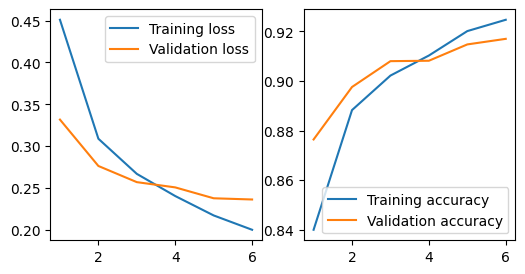

In [0]:
epochs = range(1, len(loss)+1)

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.plot(epochs, loss, label = 'Training loss')
plt.plot(epochs, val_loss, label = 'Validation loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, accuracy, label = 'Training accuracy')
plt.plot(epochs, val_accuracy, label = 'Validation accuracy')
plt.legend()

plt.show()








In [0]:
model2.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9112 - loss: 0.2556


[0.24765944480895996, 0.9125000238418579]

**Accuratetea pe multimea de testare = 0.9103**